# 第三部分 3.2：卷积神经网络（CNN）

| 章节 | 内容 |
|------|------|
| **3.4 卷积神经网络** | 卷积层、池化层、经典架构（LeNet → VGG → ResNet）|

---

In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

matplotlib.rcParams['font.family'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('环境就绪，PyTorch 版本：', torch.__version__)
print('使用设备：', device)

## 3.4 卷积神经网络（CNN）

### 为什么不直接用 MLP 处理图像？

一张 32×32 RGB 图像有 `32 × 32 × 3 = 3072` 个像素。如果用全连接层，输入层就有 3072 个神经元，第一个隐藏层假设有 1000 个神经元，光这一层就有 **300 万个参数**（3072 × 1000 = 3,072,000）。对于 224×224 的图像，参数量爆炸式增长。

更根本的问题：**MLP 把图像展平成一维向量，丢失了空间结构**。「猫的左耳和右耳相邻」这类空间关系，展平后就消失了。

---

### 卷积层的核心思想

CNN 的解决方案基于两个关键假设：

1. **局部性（Locality）**：图像中的特征（边缘、纹理、角点）只依赖局部区域，不需要看整张图
2. **平移不变性（Translation Invariance）**：同样的特征在图像的任何位置都应被识别（左上角的猫耳和右下角的猫耳，用同一套参数检测）

**卷积操作**：用一个小的**卷积核（Kernel / Filter）** 在整张图上滑动，每次只看一个局部区域（感受野），输出该区域的特征响应。

```
输入图像（H × W）+ 卷积核（k × k）→ 特征图（Feature Map）

每个输出位置 = 卷积核 与 对应局部区域 的 点积 + 偏置
```

**参数共享**：同一个卷积核在整张图上都用相同的权重。一个 3×3 卷积核只有 9 个参数，却能处理整张图——这是 CNN 参数效率极高的根本原因。

---

### 关键超参数

| 超参数 | 含义 | 典型值 |
|--------|------|--------|
| **kernel_size** | 卷积核大小 | 3×3（最常用）、5×5、1×1 |
| **stride** | 卷积核每次移动的步长 | 1（默认）、2（下采样，替代池化）|
| **padding** | 在图像边缘填充 0 的圈数 | 1（保持特征图大小不变，当 kernel=3 时）|
| **out_channels** | 卷积核数量（学习多少种特征）| 16/32/64/128 |

输出特征图大小公式（以单边为例）：
$$H_{out} = \left\lfloor \frac{H_{in} + 2 \times \text{padding} - \text{kernel\_size}}{\text{stride}} \right\rfloor + 1$$

---

### 池化层（Pooling）

池化层减少特征图的空间尺寸（宽高），同时保留最重要的特征。

- **Max Pooling**：取局部区域的最大值。最常用，保留最强的激活信号
- **Average Pooling**：取局部区域的平均值。用于网络末端（全局平均池化）

**MaxPool 2×2 的计算过程**：把特征图划分成不重叠的 2×2 格子，每个格子只保留最大值，空间尺寸减半：

```
原始特征图（4×4）              MaxPool 后（2×2）

  1  3 | 2  1              左上 {1,3,0,4} → 4    右上 {2,1,1,2} → 2
  0  4 | 1  2      →                                                →   4  2
 ------+------              左下 {2,1,0,2} → 2    右下 {5,3,3,4} → 5       2  5
  2  1 | 5  3
  0  2 | 3  4
```

**池化会丢失信息，为什么是好事？**

池化丢掉的是"特征精确在哪个像素"，保留的是"这个区域有没有这个特征"。以检测猫耳朵为例：卷积核在某个 2×2 区域里扫到了强响应，这个响应在格子内的具体位置（左上还是右下）其实不重要，重要的是**这个区域有猫耳朵**。MaxPool 取最大值，正好保留了"有没有"，丢掉了"精确在哪"。

这也是 CNN 能做到**平移不变性**的原因之一——猫耳朵往左挪了一两个像素，经过池化后结果几乎不变，模型不会因为位置的微小偏移就认不出来。

另一个好处是**减少计算量**：特征图从 32×32 变成 16×16，数据量缩小到 1/4，这让后续卷积层可以用更多通道（16 → 32 → 64）在不爆显存的前提下检测更多种类的特征。

**池化 vs 下采样**

两者不完全等价。"下采样"是目的——减小空间尺寸；池化是实现下采样的一种手段，但不是唯一的。现代网络（如 ResNet）也常用 `stride=2` 的卷积层代替池化来做下采样，参数可学习，效果相近。所以说"池化层做下采样"是对的，反过来说"下采样就是池化"则不一定。

**全局平均池化（Global Average Pooling, GAP）**：直接对整个特征图取平均，将 `C × H × W` 的特征图压缩为 `C` 维向量。相比全连接层参数更少，是现代网络（ResNet 之后）的标准做法。

---

### 经典架构演进

CNN 架构经历了从手工设计到自动搜索的演进历程，每一代架构都解决了上一代的核心瓶颈：

| 架构 | 年份 | 创新点 | 核心局限 |
|------|------|--------|----------|
| **LeNet-5** | 1998 | 卷积 + 池化 + 全连接，首次成功应用 | 网络太浅，只能处理简单任务 |
| **AlexNet** | 2012 | 深层网络 + ReLU + Dropout + GPU 训练，ImageNet 冠军 | 全连接层参数量巨大（6000万参数）|
| **VGG** | 2014 | 全部用 3×3 小卷积核堆叠，结构简洁规律 | 深度受限：深层网络退化问题，梯度难以传播 |
| **ResNet** | 2015 | **残差连接（Skip Connection）**，训练 152 层网络 | - |

---

### 一个典型 CNN 的完整结构

以 LeNet 风格为例，一个处理 32×32 彩色图像的 CNN 通常由三个阶段组成：

**阶段一：特征提取（卷积块）**

卷积层和池化层交替堆叠，负责从图像中提取越来越抽象的特征。每经过一次 MaxPool，空间尺寸减半，但通道数通常翻倍——用更多的特征图来补偿损失的空间信息。

```
输入 32×32×3
  → Conv1 + ReLU  → 特征图 32×32×16   # 检测边缘、颜色等低级特征
  → MaxPool       → 特征图 16×16×16   # 空间减半，保留最强响应
  → Conv2 + ReLU  → 特征图 16×16×32   # 检测纹理、角点等中级特征
  → MaxPool       → 特征图  8×8×32    # 再次减半
  → Conv3 + ReLU  → 特征图  8×8×64   # 检测更抽象的组合特征
  → MaxPool       → 特征图  4×4×64   # 最终空间压缩到 4×4
```

**阶段二：展平（Flatten）**

卷积输出是三维张量 `(C, H, W)`，全连接层需要一维向量输入。Flatten 把 `4×4×64 = 1024` 个数值按顺序排成一列，作为分类器的输入。

**阶段三：分类头（全连接层）**

接收展平后的特征向量，通过几层全连接 + ReLU 进一步整合全局信息，最后一层输出每个类别的得分（logit），经过 Softmax 转换为概率。

```
Flatten → 1024 维向量
  → FC + ReLU  → 256 维   # 整合特征
  → FC + ReLU  → 128 维
  → FC         → 10 维    # 10 个类别的原始得分
  → Softmax    → 10 个概率（加和为 1）
```

下面是这个结构的完整示意图：

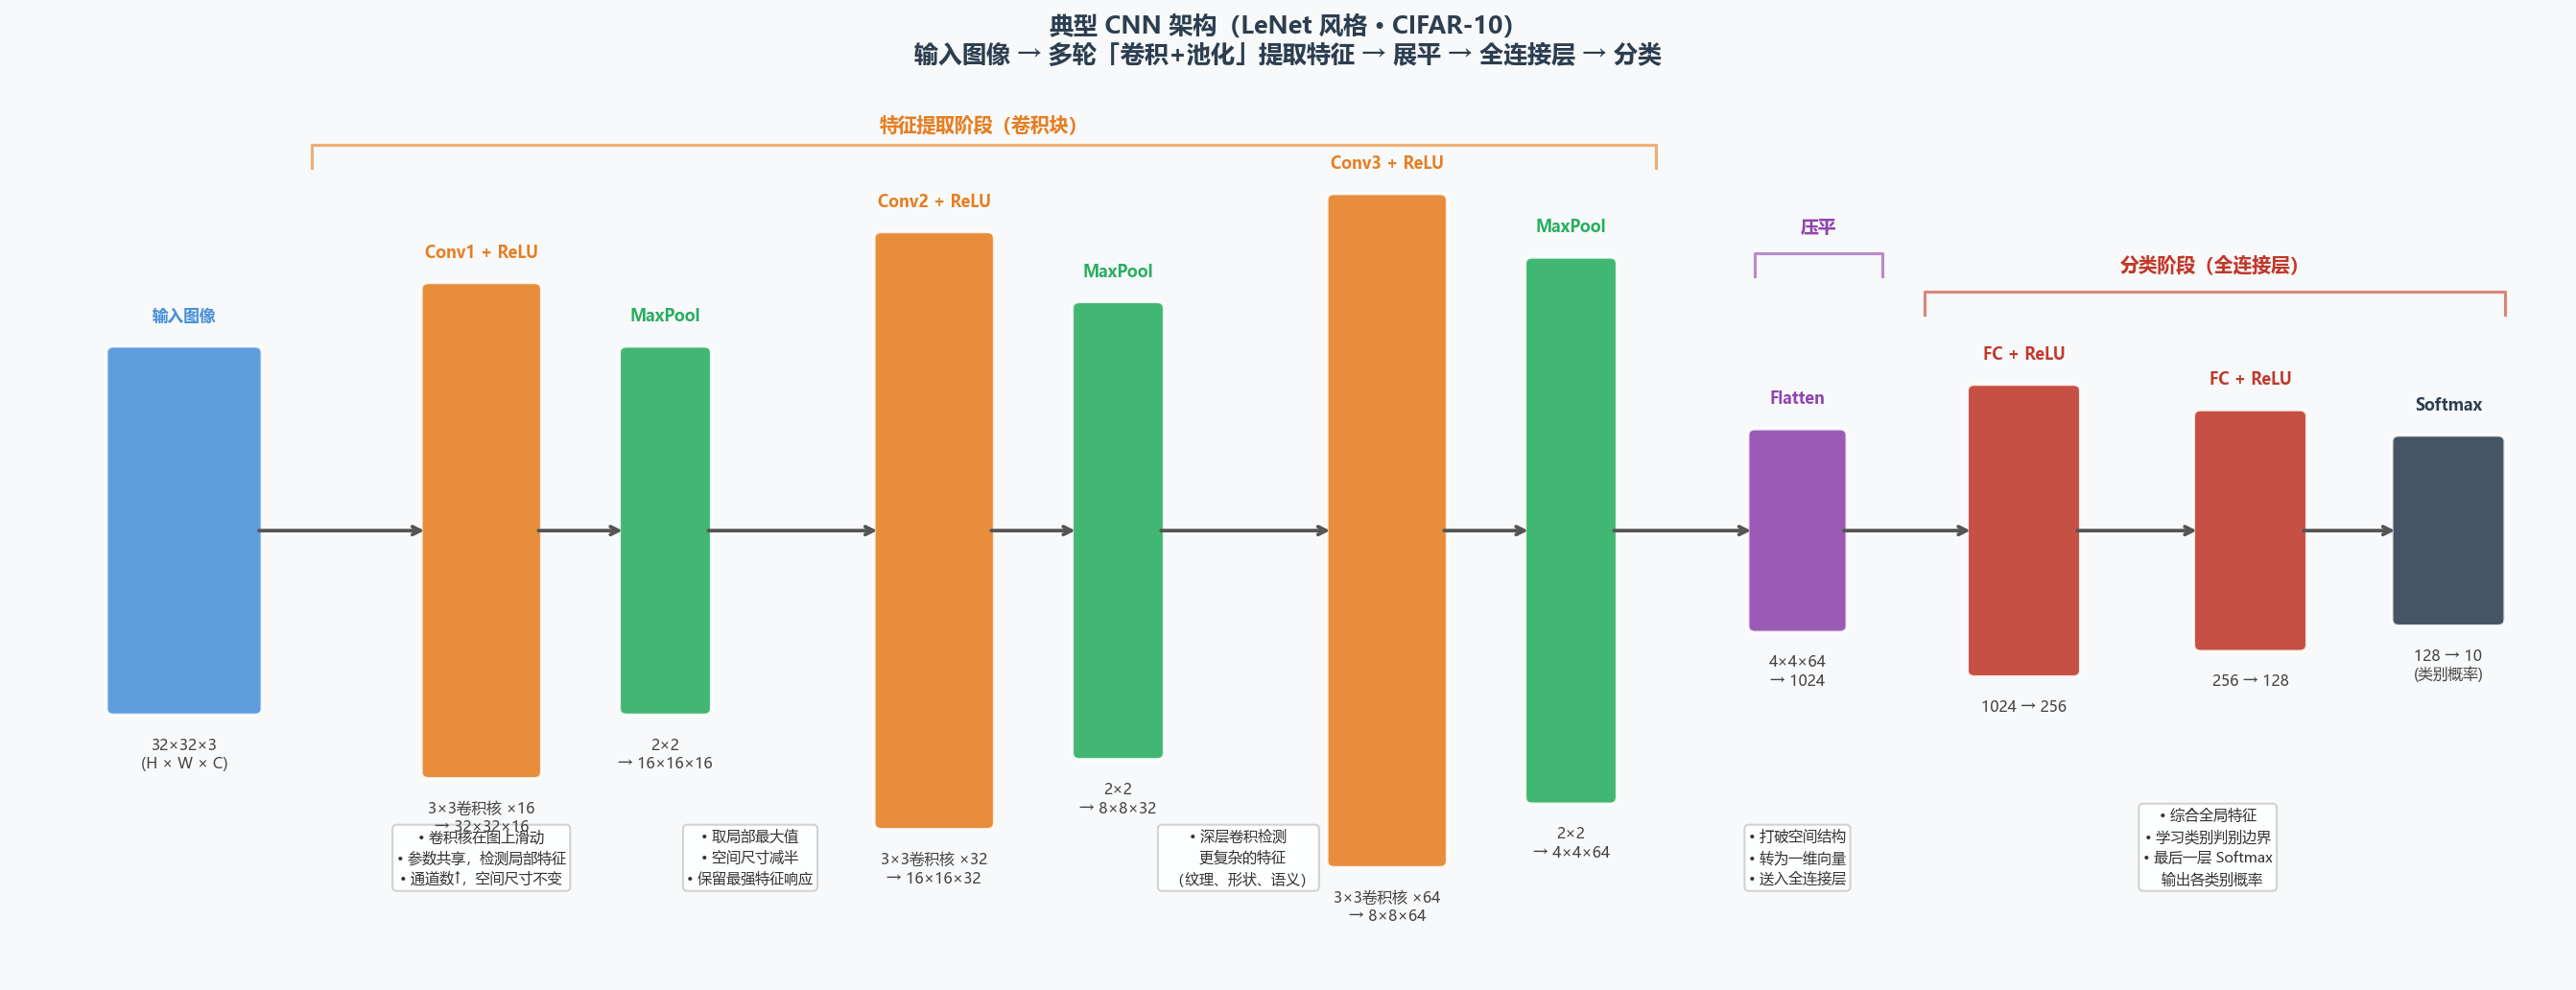

## 附录一：卷积核从哪里来？

### 经典计算机视觉时代：手工设计

Sobel、高斯模糊、锐化……这些都是人类花了几十年总结出来的"有用卷积核"。它们确实管用，但有一个根本限制：**人类只能设计自己能理解的特征**。边缘、纹理可以描述，但"这张图里有猫"这种高层语义，没法用几个手工 kernel 表达出来。

### CNN 的思路：让数据告诉你什么 kernel 有用

CNN 一开始把所有 kernel 的值初始化为随机小数。训练时，每次预测错了，就通过反向传播计算"把哪个 kernel 的哪个权重往哪个方向调一点点，损失会减小"，然后用梯度下降更新。重复几万次之后，kernel 自然收敛到对当前任务最有用的形态。

**有趣的地方在于：学出来的 kernel 和手工设计的很像。** 对训练好的 CNN 第一层卷积核可视化，会发现它们自发地学出了 Sobel 类似的边缘检测器、颜色对比检测器——这说明"边缘对识别图像有用"这件事，网络自己从数据里发现了。

但越往深走，kernel 检测的东西越抽象：

```
第 1 层 kernel：边缘、颜色梯度         ← 人类能理解
第 2 层 kernel：纹理、角点             ← 勉强能理解
第 3 层 kernel：眼睛形状、毛发走向     ← 说不太清楚
第 5 层 kernel："猫脸的某个组合特征"  ← 人类完全无法设计
```

深层 kernel 检测的特征没有人类语言能准确描述，但它们对分类任务极其有效——这正是手工设计无法企及的地方。

| | 手工 kernel（Sobel 等） | CNN 学到的 kernel |
|---|---|---|
| 怎么来的 | 人类经验设计 | 从数据里自动学 |
| 浅层效果 | 与学到的相近（都是边缘检测等） | 自动发现，无需人工 |
| 深层能力 | 无法设计 | 自动学出抽象特征 |
| 适用范围 | 通用，任务无关 | 针对具体任务优化 |

> Sobel 这类核是"人类智慧的上限"，CNN 的学习过程是"用数据突破这个上限"。

下面的演示用手工设计的经典卷积核来帮助理解卷积的工作原理——在真实 CNN 中，这些 kernel 的值是通过训练自动学出来的，不需要人工指定。

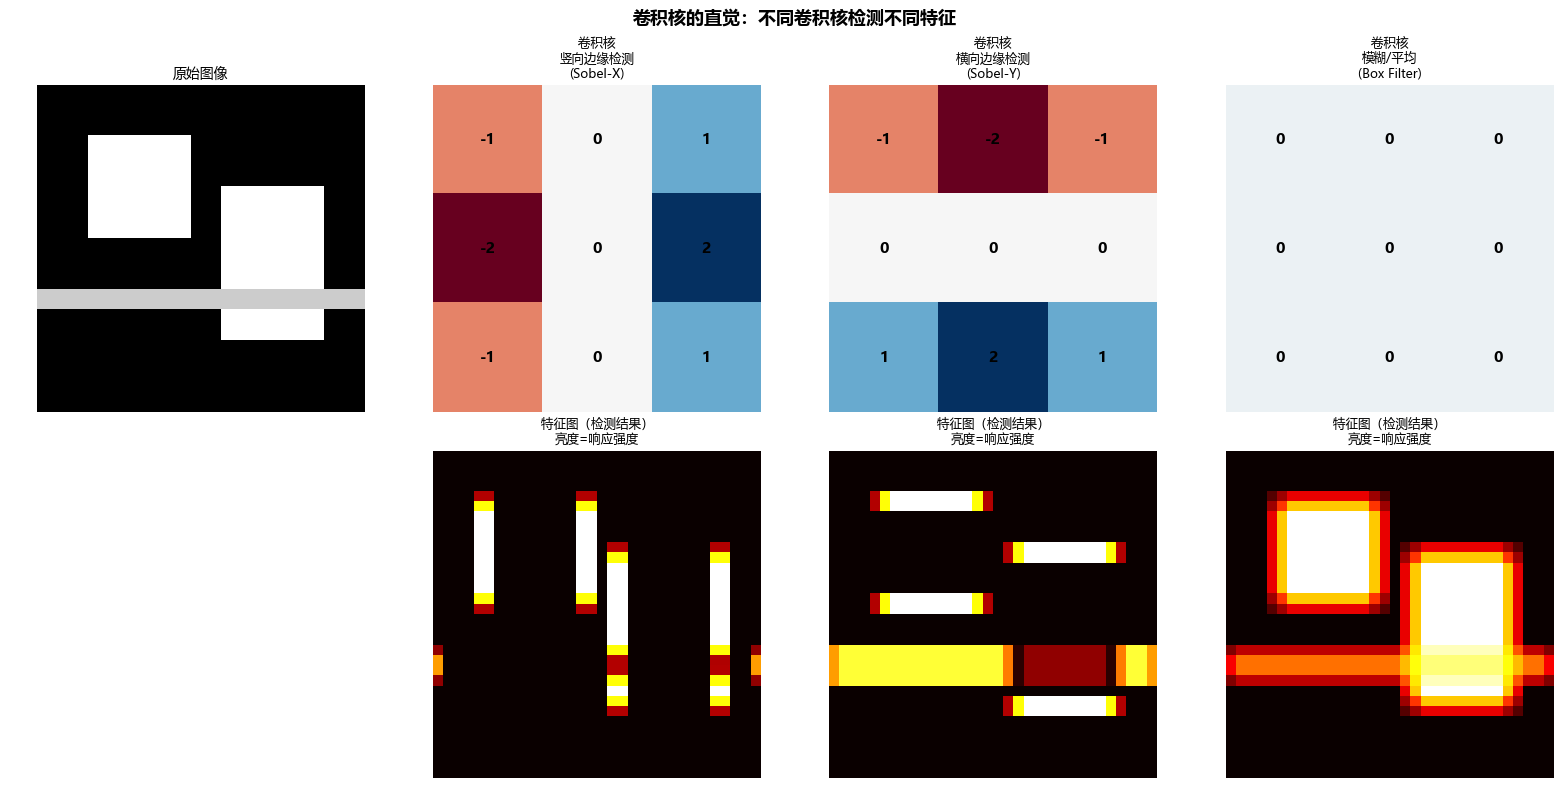

观察：
  Sobel-X（竖向边缘）：对垂直方向的颜色变化强烈响应 → 检测竖边
  Sobel-Y（横向边缘）：对水平方向的颜色变化强烈响应 → 检测横边
  Box Filter（模糊）  ：对局部均值响应 → 平滑图像
  CNN 训练时会自动学习出这些有用的卷积核，无需手工设计


In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ── 演示 1：卷积核的直觉 ────────────────────────────────────────
# 手工设计几个经典卷积核，展示它们分别能检测什么特征

# 用于演示的合成图像：黑白棋盘 + 几何形状
img_size = 32
img = np.zeros((img_size, img_size), dtype=np.float32)
img[5:15, 5:15] = 1.0      # 白色方块（左上）
img[10:25, 18:28] = 1.0    # 白色方块（右中），两块有垂直边缘相交
# 加一条水平条纹
img[20:22, :] = 0.8

# 三种经典卷积核
kernels = {
    '竖向边缘检测\n(Sobel-X)': np.array([[-1, 0, 1],
                                          [-2, 0, 2],
                                          [-1, 0, 1]], dtype=np.float32),
    '横向边缘检测\n(Sobel-Y)': np.array([[-1, -2, -1],
                                          [ 0,  0,  0],
                                          [ 1,  2,  1]], dtype=np.float32),
    '模糊/平均\n(Box Filter)': np.ones((3, 3), dtype=np.float32) / 9,
}

# 用 PyTorch 的 F.conv2d 做卷积（等价于 nn.Conv2d 但可以手动指定权重）
import torch.nn.functional as F

# ── PyTorch 张量维度说明 ────────────────────────────────────────
# F.conv2d 要求输入是 4D 张量，格式为 (N, C, H, W)：
#   N = batch size（一次处理多少张图，这里只有 1 张）
#   C = channels（通道数，灰度图是 1，RGB 是 3）
#   H = height（图像高度）
#   W = width（图像宽度）
#
# img 现在是 numpy 数组，shape = (32, 32)，即 (H, W)
# 需要两次 unsqueeze 在最前面各加一个维度：
#   unsqueeze(0)：(32, 32) → (1, 32, 32)    加上 batch 维度 N
#   unsqueeze(0)：(1, 32, 32) → (1, 1, 32, 32)  再加上 channel 维度 C
img_t = torch.FloatTensor(img).unsqueeze(0).unsqueeze(0)  # shape: (1, 1, 32, 32)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('卷积核的直觉：不同卷积核检测不同特征', fontsize=13, fontweight='bold')

axes[0][0].imshow(img, cmap='gray', vmin=0, vmax=1)
axes[0][0].set_title('原始图像', fontsize=10)
axes[0][0].axis('off')
axes[1][0].axis('off')  # 占位

for i, (name, kernel) in enumerate(kernels.items(), 1):
    # kernel 是 numpy 数组，shape = (3, 3)，即 (kH, kW)
    # F.conv2d 要求卷积核也是 4D 张量，格式为 (out_channels, in_channels, kH, kW)：
    #   out_channels = 1（输出 1 张特征图，因为只有 1 个卷积核）
    #   in_channels  = 1（输入是单通道灰度图）
    #   kH, kW       = 3, 3（卷积核的高和宽）
    # 同样需要两次 unsqueeze(0)：(3,3) → (1,3,3) → (1,1,3,3)
    k_t = torch.FloatTensor(kernel).unsqueeze(0).unsqueeze(0)  # shape: (1, 1, 3, 3)

    # F.conv2d(input, weight, padding=1)
    #   input   : 待卷积的图像张量，shape (1, 1, 32, 32)
    #   weight  : 卷积核张量，     shape (1, 1, 3, 3)
    #   padding : 在图像四周填充 1 圈 0，使输出特征图与输入同等大小（32×32 → 32×32）
    #             不加 padding 时，3×3 卷积会让输出缩小：32 → 30
    # 输出 shape: (1, 1, 32, 32)，即 (N, out_channels, H, W)
    out_t = F.conv2d(img_t, k_t, padding=1)

    # squeeze() 去掉所有大小为 1 的维度：(1, 1, 32, 32) → (32, 32)
    # .numpy() 把 PyTorch 张量转回 numpy 数组，方便 matplotlib 显示
    out = out_t.squeeze().numpy()

    # 上：显示卷积核本身（3×3）
    axes[0][i].imshow(kernel, cmap='RdBu', vmin=-2, vmax=2)
    for r in range(3):
        for c in range(3):
            axes[0][i].text(c, r, f'{kernel[r, c]:.0f}',
                            ha='center', va='center', fontsize=11, fontweight='bold')
    axes[0][i].set_title(f'卷积核\n{name}', fontsize=9)
    axes[0][i].axis('off')

    # 下：显示卷积后的特征图
    # np.abs(out)：边缘检测卷积核的输出可以是负值（像素从亮→暗），取绝对值后
    # 正负边缘都显示为亮色，更直观地看出"哪里有边缘"
    axes[1][i].imshow(np.abs(out), cmap='hot')
    axes[1][i].set_title(f'特征图（检测结果）\n亮度=响应强度', fontsize=9)
    axes[1][i].axis('off')

plt.tight_layout()
plt.show()

print("观察：")
print("  Sobel-X（竖向边缘）：对垂直方向的颜色变化强烈响应 → 检测竖边")
print("  Sobel-Y（横向边缘）：对水平方向的颜色变化强烈响应 → 检测横边")
print("  Box Filter（模糊）  ：对局部均值响应 → 平滑图像")
print("  CNN 训练时会自动学习出这些有用的卷积核，无需手工设计")

## 附录二：一个典型的 CNN 网络如何构建

In [4]:
import torch
import torch.nn as nn

# 用 PyTorch 构建一个 LeNet 风格的 CNN，处理 32×32 彩色图像（3通道），输出 10 个类别

class LeNetCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # ── 阶段一：特征提取（卷积块）─────────────────────────────
        # 卷积层 + 激活函数 + 池化层 交替堆叠
        # 每经过一次 MaxPool，空间尺寸减半；通道数逐步增加，检测更多种类的特征
        self.features = nn.Sequential(

            # 第一个卷积块
            # Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
            #   输入：(B, 3, 32, 32)  → 输出：(B, 16, 32, 32)
            #   3 个输入通道（RGB），学习 16 种卷积核，每种检测一类低级特征（边缘、颜色等）
            #   padding=1 保持空间尺寸不变（32 → 32）
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),               # 非线性激活，负值置 0，保留有响应的特征
            # MaxPool2d(2)：2×2 区域取最大值，空间尺寸减半
            #   输出：(B, 16, 32, 32) → (B, 16, 16, 16)
            nn.MaxPool2d(2),

            # 第二个卷积块
            # 通道数 16 → 32：在更小的空间上检测更多种类的中级特征（纹理、角点等）
            #   输出：(B, 16, 16, 16) → (B, 32, 16, 16)
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            #   输出：(B, 32, 16, 16) → (B, 32, 8, 8)
            nn.MaxPool2d(2),

            # 第三个卷积块
            # 通道数 32 → 64：在更抽象的层次上检测高级特征（形状组合等）
            #   输出：(B, 32, 8, 8) → (B, 64, 8, 8)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            #   输出：(B, 64, 8, 8) → (B, 64, 4, 4)
            nn.MaxPool2d(2),
        )

        # ── 阶段二：展平（Flatten）────────────────────────────────
        # 卷积输出是 3D 张量 (64, 4, 4)，全连接层要求 1D 向量输入
        # Flatten 把 64 × 4 × 4 = 1024 个数值展开成一列
        self.flatten = nn.Flatten()

        # ── 阶段三：分类头（全连接层）────────────────────────────
        # 接收 1024 维特征向量，逐步压缩并整合全局信息，最终输出 10 个类别的得分
        self.classifier = nn.Sequential(
            # 1024 → 256：整合卷积提取到的特征
            nn.Linear(1024, 256),
            nn.ReLU(),
            # 256 → 10：输出每个类别的原始得分（logit）
            # 注意：不加 Softmax，CrossEntropyLoss 内部会处理
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.features(x)    # 特征提取：(B,3,32,32) → (B,64,4,4)
        x = self.flatten(x)     # 展平：(B,64,4,4) → (B,1024)
        x = self.classifier(x)  # 分类：(B,1024) → (B,10)
        return x


model = LeNetCNN()
print(model)

# 统计各阶段参数量
def count_params(m):
    return sum(p.numel() for p in m.parameters())

print(f"\n特征提取（卷积块）参数量：{count_params(model.features):,}")
print(f"分类头（全连接层）参数量：{count_params(model.classifier):,}")
print(f"总参数量：              {count_params(model):,}")

# 追踪每一层的特征图尺寸变化
print("\n── 特征图尺寸变化 ──────────────────────────────")
x = torch.zeros(1, 3, 32, 32)
print(f"  输入              {tuple(x.shape)}")
for layer in model.features:
    x = layer(x)
    print(f"  {type(layer).__name__:<20} → {tuple(x.shape)}")
x = model.flatten(x)
print(f"  {'Flatten':<20} → {tuple(x.shape)}")
for layer in model.classifier:
    x = layer(x)
    print(f"  {type(layer).__name__:<20} → {tuple(x.shape)}")

LeNetCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (classifier): Sequential(
    (0): Linear(in_features=1024, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=10, bias=True)
  )
)

特征提取（卷积块）参数量：23,584
分类头（全连接层）参数量：264,970
总参数量：              288,554

── 特征图尺寸变化 ──────────────────────────────
  输入              (1, 3, 32, 32)
  Conv2d               → (1, 16, 32, 32)
  ReLU                 → (1, 1

## 附录三：实战例子——CIFAR-10 图像分类

=== CIFAR-10 图像分类：SmallResNet 训练 ===
  数据集：CIFAR-10，60000 张 32×32 彩色图，10 个类别
  类别：飞机/汽车/鸟/猫/鹿/狗/青蛙/马/船/卡车

训练集大小：5000 张（完整数据集的 1/10，演示用）
测试集大小：10000 张



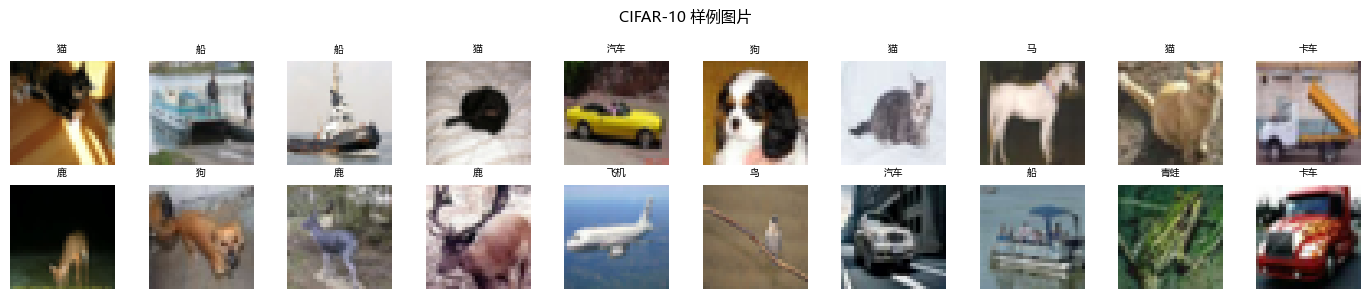

训练 3 轮（设备：cpu）...
  Epoch 1/3  Loss=1.878  测试准确率=0.347
  Epoch 2/3  Loss=1.676  测试准确率=0.354
  Epoch 3/3  Loss=1.533  测试准确率=0.323


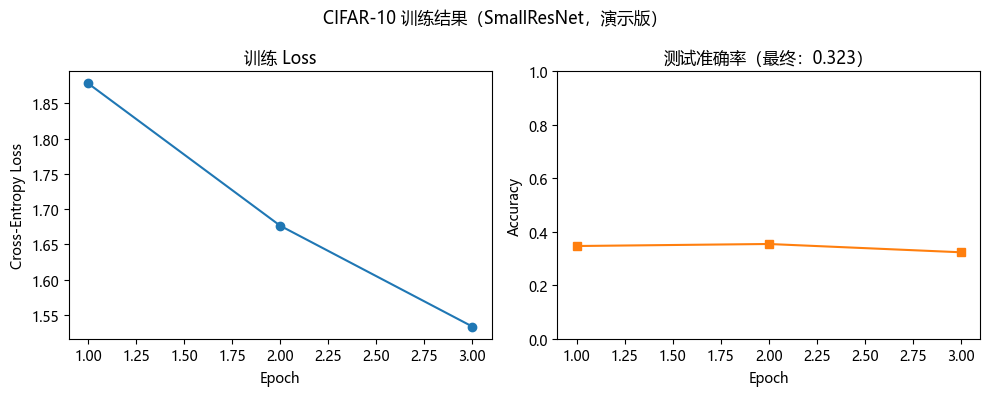


最终测试准确率：0.323
CIFAR-10 随机猜测基准：0.100（10类均等）
→ 仅用 1/10 数据、3 轮训练，准确率已明显超过随机基准
  完整训练（50000 张 × 20 轮，GPU）可达 0.85+


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)

# ── SmallResNet 定义 ────────────────────────────────────────────
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = x
        out = self.block(x)
        out = out + residual      # 残差连接：输出 = F(x) + x
        return self.relu(out)

class SmallResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.layer1 = nn.Sequential(ResidualBlock(32), ResidualBlock(32))
        self.down1  = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True)
        )
        self.layer2 = nn.Sequential(ResidualBlock(64), ResidualBlock(64))
        self.down2  = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True)
        )
        self.layer3 = nn.Sequential(ResidualBlock(128), ResidualBlock(128))
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.down1(x)
        x = self.layer2(x)
        x = self.down2(x)
        x = self.layer3(x)
        return self.head(x)

# ── CIFAR-10 实战训练 ───────────────────────────────────────────
print("=== CIFAR-10 图像分类：SmallResNet 训练 ===")
print("  数据集：CIFAR-10，60000 张 32×32 彩色图，10 个类别")
print("  类别：飞机/汽车/鸟/猫/鹿/狗/青蛙/马/船/卡车")
print()

# 数据预处理
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_set_full = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_train)
test_set       = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# 只取前 5000 张训练图，CPU 演示用，避免等待时间过长
# 完整训练（50000 张 × 20 轮）在 GPU 上跑，CPU 上需要数小时
train_set = Subset(train_set_full, indices=range(5000))

train_loader = DataLoader(train_set, batch_size=128, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False, num_workers=0)

print(f"训练集大小：{len(train_set)} 张（完整数据集的 1/10，演示用）")
print(f"测试集大小：{len(test_set)} 张")
print()

# 可视化数据集样例
classes = ['飞机','汽车','鸟','猫','鹿','狗','青蛙','马','船','卡车']
imgs, lbls = next(iter(DataLoader(test_set, batch_size=20, shuffle=True)))

fig, axes = plt.subplots(2, 10, figsize=(14, 3))
fig.suptitle('CIFAR-10 样例图片', fontsize=11)
mean = np.array([0.4914, 0.4822, 0.4465])
std  = np.array([0.2023, 0.1994, 0.2010])
for i in range(20):
    ax = axes[i // 10][i % 10]
    img_show = imgs[i].numpy().transpose(1, 2, 0) * std + mean
    ax.imshow(np.clip(img_show, 0, 1))
    ax.set_title(classes[lbls[i].item()], fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()

# 训练
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = SmallResNet(num_classes=10).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn   = nn.CrossEntropyLoss()

EPOCHS = 3
train_losses, test_accs = [], []

print(f"训练 {EPOCHS} 轮（设备：{device}）...")
for ep in range(EPOCHS):
    model.train()
    ep_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()
        ep_loss += loss.item()

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
            total   += yb.size(0)
    acc = correct / total
    avg_loss = ep_loss / len(train_loader)
    train_losses.append(avg_loss)
    test_accs.append(acc)
    print(f"  Epoch {ep+1}/{EPOCHS}  Loss={avg_loss:.3f}  测试准确率={acc:.3f}")

# 训练曲线
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('CIFAR-10 训练结果（SmallResNet，演示版）', fontsize=12)
axes[0].plot(range(1, EPOCHS+1), train_losses, 'o-', color='C0', lw=1.5)
axes[0].set_title('训练 Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[1].plot(range(1, EPOCHS+1), test_accs, 's-', color='C1', lw=1.5)
axes[1].set_title(f'测试准确率（最终：{test_accs[-1]:.3f}）')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

print(f"\n最终测试准确率：{test_accs[-1]:.3f}")
print(f"CIFAR-10 随机猜测基准：0.100（10类均等）")
print(f"→ 仅用 1/10 数据、3 轮训练，准确率已明显超过随机基准")
print(f"  完整训练（50000 张 × 20 轮，GPU）可达 0.85+")